In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

mukeshkumarmoharana_ai_vs_real_path = kagglehub.dataset_download('mukeshkumarmoharana/ai-vs-real')
birdy654_cifake_real_and_ai_generated_synthetic_images_path = kagglehub.dataset_download('birdy654/cifake-real-and-ai-generated-synthetic-images')
mukeshkumarmoharana_fake_msk_path = kagglehub.dataset_download('mukeshkumarmoharana/fake-msk')

print('Data source import complete.')


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                              precision_score, recall_score, classification_report)
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

Device: cuda


In [ ]:
os.system("pip install open_clip_torch -q")
import open_clip
print("open_clip loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
open_clip loaded


In [ ]:
TRAIN_DIR = '/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train'
TEST_DIR  = '/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test'

print(os.listdir(TRAIN_DIR))  # ['FAKE', 'REAL']
print(os.listdir(TEST_DIR))   # ['FAKE', 'REAL']

['FAKE', 'REAL']
['FAKE', 'REAL']


In [ ]:
# CLIP-specific normalization — do NOT use ImageNet constants
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std =(0.26862954, 0.26130258, 0.27577711)
    )
])

clip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275,  0.40821073),
        std =(0.26862954, 0.26130258, 0.27577711)
    )
])

print("Transforms ready")

Transforms ready


In [ ]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset  = ImageFolder(TEST_DIR,  transform=clip_transform)

# num_workers=2, pin_memory=False for Kaggle stability
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=False)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Classes       : {train_dataset.classes}")  # ['FAKE', 'REAL']

Train samples : 100000
Test  samples : 20000
Classes       : ['FAKE', 'REAL']


In [ ]:
class UnivFDDetector(nn.Module):
    def __init__(self, clip_model='ViT-B-16', pretrained='openai', dropout=0.2):
        super().__init__()

        # Load CLIP visual encoder
        clip, _, _ = open_clip.create_model_and_transforms(
            clip_model, pretrained=pretrained
        )
        self.backbone = clip.visual

        # Freeze ALL 86M backbone parameters
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Only 513 parameters will train
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 1)
        )

        frozen    = sum(p.numel() for p in self.backbone.parameters())
        trainable = sum(p.numel() for p in self.classifier.parameters())
        print(f"Frozen params    : {frozen:,}")
        print(f"Trainable params : {trainable:,}")

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x).float()  # (B, 512)
        return self.classifier(features).squeeze(1)

    def extract_features(self, x):
        with torch.no_grad():
            return self.backbone(x).float()

model = UnivFDDetector().to(DEVICE)

open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Frozen params    : 86,192,640
Trainable params : 513


In [ ]:
# Since backbone is frozen, extract features ONCE and reuse
# This avoids running CLIP on every epoch

def extract_all_features(model, loader, device):
    model.eval()
    all_feats, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting"):
            feats = model.extract_features(images.to(device))
            all_feats.append(feats.cpu())
            all_labels.append(labels)
    return torch.cat(all_feats), torch.cat(all_labels)

print("Extracting train features...")
train_feats, train_labels = extract_all_features(model, train_loader, DEVICE)

print("Extracting test features...")
test_feats, test_labels = extract_all_features(model, test_loader, DEVICE)

print(f"Train features shape : {train_feats.shape}")  # (100000, 512)
print(f"Test  features shape : {test_feats.shape}")   # (20000, 512)

Extracting train features...


Extracting:   0%|          | 0/1563 [00:00<?, ?it/s]

Extracting test features...


Extracting:   0%|          | 0/313 [00:00<?, ?it/s]

Train features shape : torch.Size([100000, 512])
Test  features shape : torch.Size([20000, 512])


In [ ]:
# Now train only on 512-dim vectors — much lighter on RAM
train_feat_ds = TensorDataset(train_feats, train_labels)
test_feat_ds  = TensorDataset(test_feats,  test_labels)

train_feat_loader = DataLoader(train_feat_ds, batch_size=256, shuffle=True)
test_feat_loader  = DataLoader(test_feat_ds,  batch_size=256, shuffle=False)

print("Feature loaders ready")

Feature loaders ready


In [ ]:
criterion = nn.BCEWithLogitsLoss()

# Only pass classifier parameters — NOT model.parameters()
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)

print("Optimizer ready")

Optimizer ready


In [ ]:
def evaluate(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for feats, labels in loader:
            feats = feats.to(device)
            logits = model.classifier(feats).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_labels)

In [ ]:
best_auc = 0
history  = {'loss': [], 'auc': []}

for epoch in range(1, 11):
    model.train()
    running_loss = 0

    for feats, labels in tqdm(train_feat_loader, desc=f"Epoch {epoch}/10"):
        feats  = feats.to(DEVICE)
        labels = labels.float().to(DEVICE)

        optimizer.zero_grad()
        logits = model.classifier(feats).squeeze(1)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()

    avg_loss = running_loss / len(train_feat_loader)
    probs, lbls = evaluate(model, test_feat_loader, DEVICE)
    auc = roc_auc_score(lbls, probs)

    history['loss'].append(avg_loss)
    history['auc'].append(auc)

    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), 'model5_best.pth')
        print(f"           ✓ Best model saved — AUC: {best_auc:.4f}")

Epoch 1/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 01 | Loss: 0.4358 | AUC: 0.9466
           ✓ Best model saved — AUC: 0.9466


Epoch 2/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 02 | Loss: 0.3217 | AUC: 0.9571
           ✓ Best model saved — AUC: 0.9571


Epoch 3/10:   0%|          | 0/391 [00:00<?, ?it/s]

...

Epoch 08 | Loss: 0.2688 | AUC: 0.9682
           ✓ Best model saved — AUC: 0.9682


Epoch 9/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 09 | Loss: 0.2673 | AUC: 0.9684
           ✓ Best model saved — AUC: 0.9684


Epoch 10/10:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 10 | Loss: 0.2672 | AUC: 0.9684
           ✓ Best model saved — AUC: 0.9684


In [ ]:
model.load_state_dict(torch.load('model5_best.pth', map_location=DEVICE))

probs, labels = evaluate(model, test_feat_loader, DEVICE)
preds = (probs > 0.5).astype(int)

print("=" * 50)
print("   Model 5: Frozen CLIP + Linear Probe (UnivFD)")
print("=" * 50)
print(f"AUC-ROC   : {roc_auc_score(labels, probs):.4f}")
print(f"Accuracy  : {accuracy_score(labels, preds)*100:.2f}%")
print(f"Precision : {precision_score(labels, preds)*100:.2f}%")
print(f"Recall    : {recall_score(labels, preds)*100:.2f}%")
print(f"F1 Score  : {f1_score(labels, preds):.4f}")
print()
print(classification_report(labels, preds, target_names=['FAKE', 'REAL']))

   Model 5: Frozen CLIP + Linear Probe (UnivFD)
AUC-ROC   : 0.9684
Accuracy  : 90.39%
Precision : 89.02%
Recall    : 92.13%
F1 Score  : 0.9055

              precision    recall  f1-score   support

        FAKE       0.92      0.89      0.90     10000
        REAL       0.89      0.92      0.91     10000

    accuracy                           0.90     20000
   macro avg       0.90      0.90      0.90     20000
weighted avg       0.90      0.90      0.90     20000



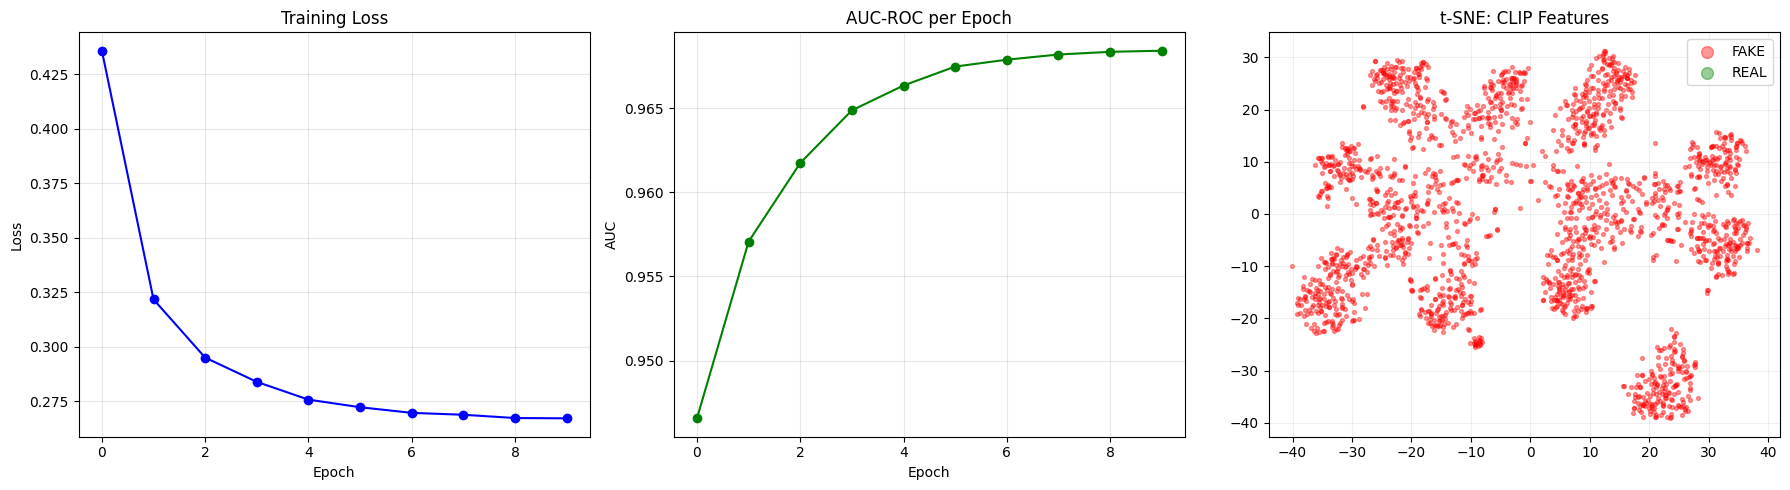

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(history['loss'], 'b-o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# AUC curve
axes[1].plot(history['auc'], 'g-o')
axes[1].set_title('AUC-ROC per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].grid(alpha=0.3)

# t-SNE
from sklearn.manifold import TSNE

sample_feats  = test_feats[:2000].numpy()
sample_labels = test_labels[:2000].numpy()

embedded = TSNE(n_components=2, random_state=42, perplexity=40).fit_transform(sample_feats)

for cls, (color, name) in enumerate(zip(['red', 'green'], ['FAKE', 'REAL'])):
    mask = sample_labels == cls
    axes[2].scatter(embedded[mask, 0], embedded[mask, 1],
                    c=color, label=name, alpha=0.4, s=8)

axes[2].set_title('t-SNE: CLIP Features')
axes[2].legend(markerscale=3)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('model5_results.png', dpi=150)
plt.show()

In [ ]:
import os

print(os.listdir("/kaggle/input/datasets/mukeshkumarmoharana/ai-vs-real/ai vs real images"))

['real images', 'ai images']


In [ ]:
base_path = "/kaggle/input/datasets/mukeshkumarmoharana/ai-vs-real/ai vs real images"

real_folder = os.path.join(base_path, "real images")
ai_folder   = os.path.join(base_path, "ai images")

In [ ]:
from PIL import Image

def predict_image(image_path, model, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")

    # IMPORTANT: use CLIP transform (you named it clip_transform)
    image = clip_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logit = model(image)
        prob = torch.sigmoid(logit).item()

    label = "REAL" if prob > 0.5 else "FAKE"

    return label, prob


In [ ]:
# Recreate model
model = UnivFDDetector().to(DEVICE)

# Load saved weights
model.load_state_dict(torch.load("model5_best.pth", map_location=DEVICE))

model.eval()

print("Model loaded successfully ✅")


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Frozen params    : 86,192,640
Trainable params : 513
Model loaded successfully ✅


In [ ]:
print("===== AI IMAGES =====")

for img_name in os.listdir(ai_folder):
    path = os.path.join(ai_folder, img_name)

    label, prob = predict_image(path, model, DEVICE)
    print(f"{img_name} → {label} ({prob:.3f})")

===== AI IMAGES =====
Joyful dog in sunlit forest trail.png → FAKE (0.000)
Sunset glow over Times Square crowd.png → FAKE (0.099)
Couple by the alpine lake.png → FAKE (0.006)
Gemini_Generated_Image_cld5kccld5kccld5 (1).png → FAKE (0.349)
Gemini_Generated_Image_cld5kccld5kccld5 (2).png → FAKE (0.068)
Gemini_Generated_Image_cld5kccld5kccld5.png → FAKE (0.001)


In [ ]:
print("\n===== REAL IMAGES =====")

for img_name in os.listdir(real_folder):
    path = os.path.join(real_folder, img_name)

    label, prob = predict_image(path, model, DEVICE)
    print(f"{img_name} → {label} ({prob:.3f})")


===== REAL IMAGES =====
RTX2FLVV-1024x650.jpg → FAKE (0.280)
10897733064_e8498bca81_k-630x422.jpg → REAL (0.647)
Prabhas.webp → REAL (0.513)
shutterstock_1495410191-scaled.jpg → FAKE (0.146)
87500673_7cec21f38a_b.jpg → FAKE (0.018)
DZ22NLYZNYUPUINFUEUSSUEN4I.avif → FAKE (0.025)


In [ ]:
correct = 0
total = 0

# AI images → should be FAKE
for img_name in os.listdir(ai_folder):
    path = os.path.join(ai_folder, img_name)
    label, _ = predict_image(path, model, DEVICE)

    if label == "FAKE":
        correct += 1
    total += 1

# Real images → should be REAL
for img_name in os.listdir(real_folder):
    path = os.path.join(real_folder, img_name)
    label, _ = predict_image(path, model, DEVICE)

    if label == "REAL":
        correct += 1
    total += 1

print(f"\nCustom Test Accuracy: {correct}/{total} = {correct/total:.2f}")


Custom Test Accuracy: 8/12 = 0.67



===== AI IMAGES =====


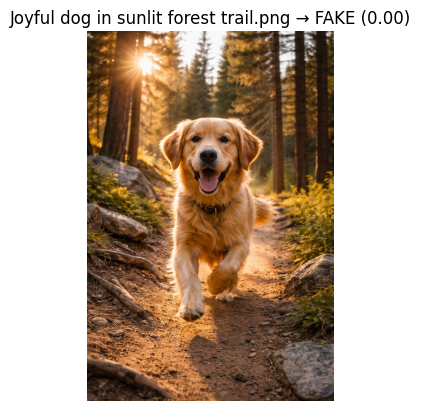

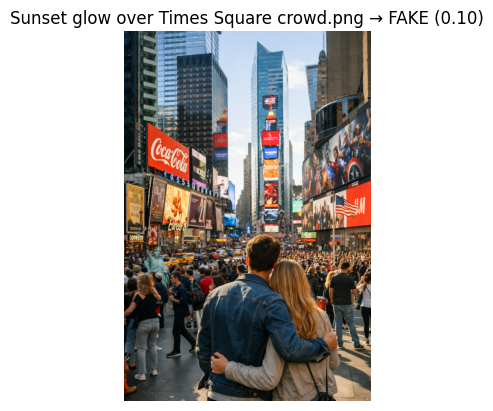

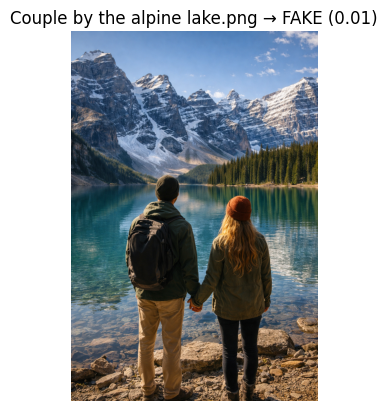

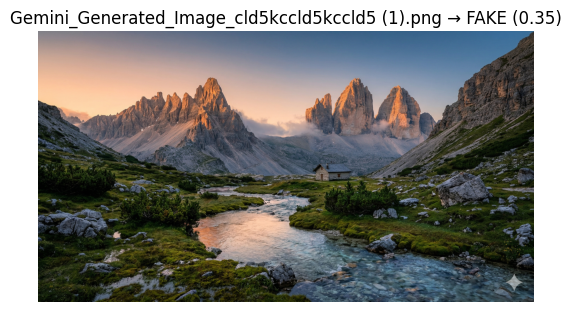

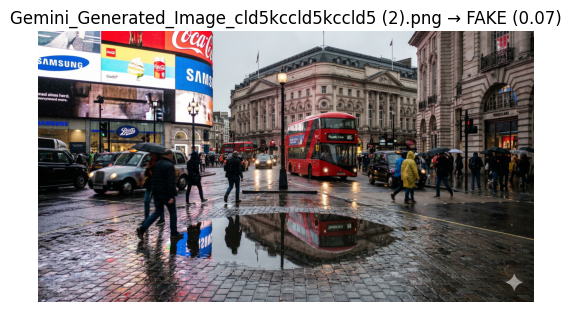

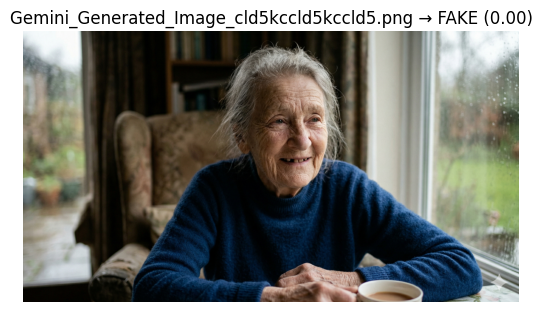


===== REAL IMAGES =====


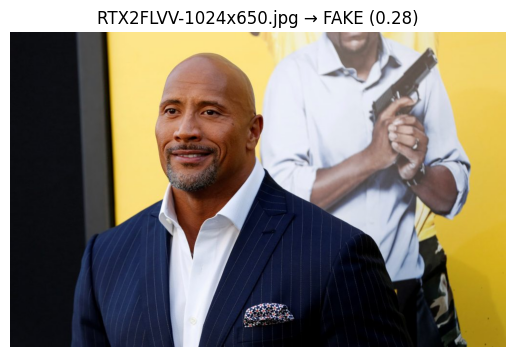

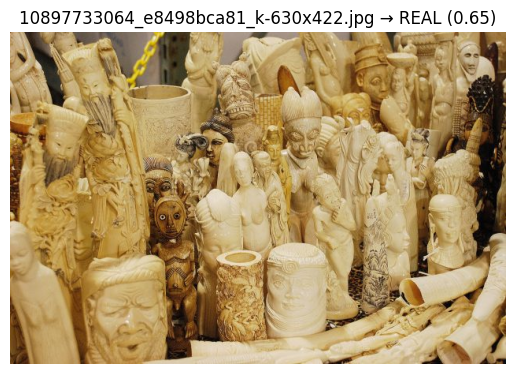

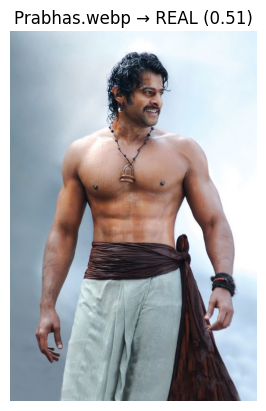

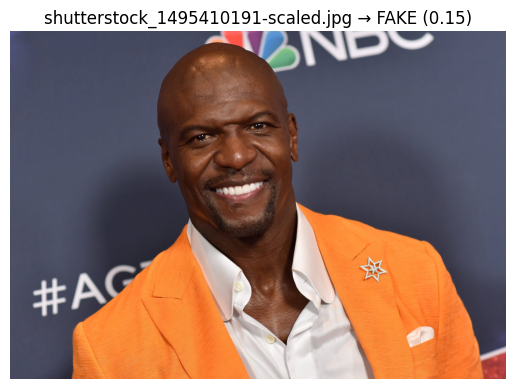

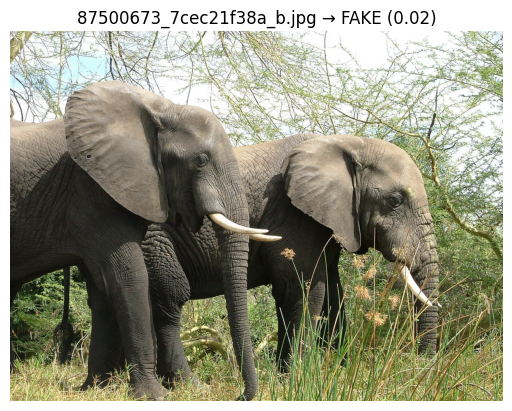

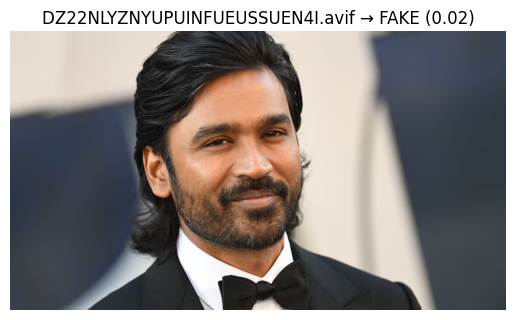

In [ ]:
import matplotlib.pyplot as plt

def show_results(folder, title):
    print(f"\n===== {title} =====")

    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)

        label, prob = predict_image(path, model, DEVICE)

        img = Image.open(path)

        plt.imshow(img)
        plt.title(f"{img_name} → {label} ({prob:.2f})")
        plt.axis("off")
        plt.show()

show_results(ai_folder, "AI IMAGES")
show_results(real_folder, "REAL IMAGES")

In [ ]:
import pandas as pd

results = []

for img_name in os.listdir(ai_folder):
    path = os.path.join(ai_folder, img_name)
    label, prob = predict_image(path, model, DEVICE)
    results.append([img_name, "AI", label, prob])

for img_name in os.listdir(real_folder):
    path = os.path.join(real_folder, img_name)
    label, prob = predict_image(path, model, DEVICE)
    results.append([img_name, "REAL", label, prob])

df = pd.DataFrame(results, columns=["Image", "Actual", "Prediction", "Confidence"])
df

,Image,Actual,Prediction,Confidence
0,Joyful dog in sunlit forest trail.png,AI,FAKE,0.000102
1,Sunset glow over Times Square crowd.png,AI,FAKE,0.098661
2,Couple by the alpine lake.png,AI,FAKE,0.005753
3,Gemini_Generated_Image_cld5kccld5kccld5 (1).png,AI,FAKE,0.348504
4,Gemini_Generated_Image_cld5kccld5kccld5 (2).png,AI,FAKE,0.068334
5,Gemini_Generated_Image_cld5kccld5kccld5.png,AI,FAKE,0.001459
6,RTX2FLVV-1024x650.jpg,REAL,FAKE,0.280393
7,10897733064_e8498bca81_k-630x422.jpg,REAL,REAL,0.646577
8,Prabhas.webp,REAL,REAL,0.512856
9,shutterstock_1495410191-scaled.jpg,REAL,FAKE,0.146098


In [ ]:
image_path = "/kaggle/input/datasets/mukeshkumarmoharana/fake-msk"


In [ ]:
label, prob = predict_image(image_path, model, DEVICE)

print(f"Prediction: {label}")
print(f"Confidence: {prob:.4f}")

IsADirectoryError: [Errno 21] Is a directory: '/kaggle/input/datasets/mukeshkumarmoharana/fake-msk'